# COURSE: A deep understanding of deep learning
## SECTION: Understand and design CNNs
### LECTURE: The EMNIST dataset (letter recognition)
#### TEACHER: Mike X Cohen, sincxpress.com
##### COURSE URL: udemy.com/course/deeplearning_x/?couponCode=202401

In [126]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
import copy
from sklearn.model_selection import train_test_split


# for importing data
import torchvision

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

from IPython.display import clear_output
import matplotlib.pyplot as plt

In [125]:
# use GPU if available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


# Import and inspect the data

In [3]:
# download the dataset
cdata = torchvision.datasets.EMNIST(root='emnist',split='letters',download=True)

# more info: https://www.nist.gov/itl/products-and-services/emnist-dataset

In [4]:
# inspect the data

# the categories (but how many letters??)
print(cdata.classes)
print(str(len(cdata.classes)) + ' classes')

print('\nData size:')
print(cdata.data.shape)

# transform to 4D tensor for conv layers (and transform from int8 to float)
images = cdata.data.view([124800,1,28,28]).float()
print('\nTensor data:')
print(images.shape)


['N/A', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
27 classes

Data size:
torch.Size([124800, 28, 28])

Tensor data:
torch.Size([124800, 1, 28, 28])


In [5]:
# brief aside: class 'N/A' doesn't exist in the data.
print( torch.sum(cdata.targets==0) )

# However, it causes problems in one-hot encoding...
torch.unique(cdata.targets)

tensor(0)


tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26])

In [6]:
cdata.class_to_idx

{'N/A': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [7]:
# so therefore we'll eliminate it and subtract 1 from the original

# remove the first class category
letterCategories = cdata.classes[1:]

# relabel labels to start at 0
labels = copy.deepcopy(cdata.targets)-1
print(labels.shape)

### 
print( torch.sum(labels==0) )
torch.unique(labels)

torch.Size([124800])
tensor(4800)


tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25])

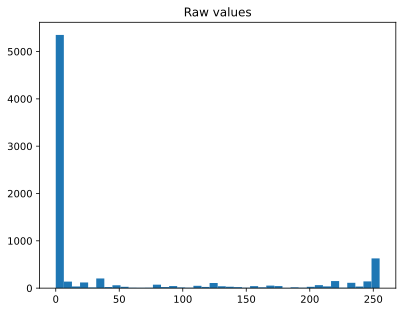

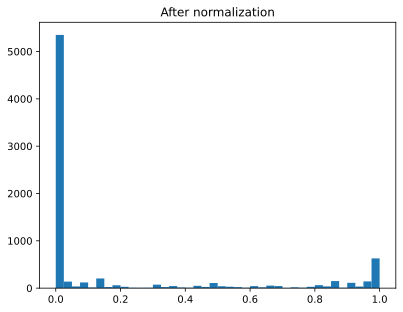

In [8]:
# next issue: do we need to normalize the images?
plt.hist(images[:10,:,:,:].view(-1).detach(),40);
plt.title('Raw values')
plt.show()

# yarp.
images /= torch.max(images)

plt.hist(images[:10,:,:,:].view(-1).detach(),40);
plt.title('After normalization')
plt.show()

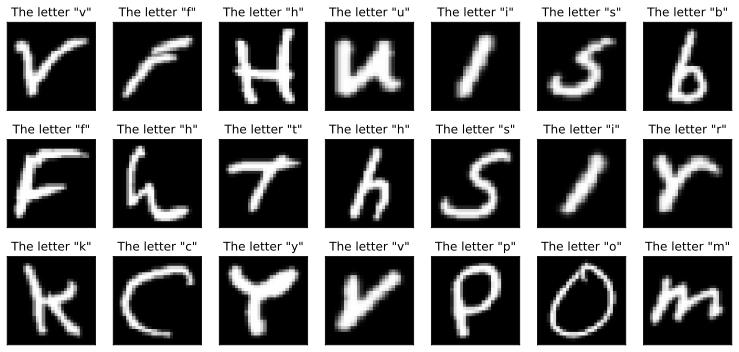

In [9]:
# visualize some images
fig,axs = plt.subplots(3,7,figsize=(13,6))

for i,ax in enumerate(axs.flatten()):

  # pick a random pic
  whichpic = np.random.randint(images.shape[0])
  
  # extract the image and its target letter
  I = np.squeeze( images[whichpic,:,:] )
  letter = letterCategories[labels[whichpic]]
  
  # visualize
  ax.imshow(I.T,cmap='gray')
  ax.set_title('The letter "%s"'%letter)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Create train/test groups using DataLoader

In [163]:
# Step 2: use scikitlearn to split the data into train/test/val sets
# 80% train, 10% test, 10% val
train_data,test_data, train_labels,test_labels = train_test_split(images, labels, test_size=.2)
test_data,val_data, test_labels,val_labels = train_test_split(test_data, test_labels, test_size=.5)

# Step 3: convert into PyTorch Datasets
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)
val_data   = TensorDataset(val_data,val_labels)

# Step 4: translate into dataloader objects
batchsize    = 32
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])
val_loader   = DataLoader(val_data,batch_size=val_data.tensors[0].shape[0])

In [161]:
# check size (should be images X channels X width X height
print( train_loader.dataset.tensors[0].shape )
print( train_loader.dataset.tensors[1].shape )
print( test_loader.dataset.tensors[0].shape )
print( test_loader.dataset.tensors[1].shape )
print( val_loader.dataset.tensors[0].shape )
print( val_loader.dataset.tensors[1].shape )

torch.Size([99840, 1, 28, 28])
torch.Size([99840])
torch.Size([12480, 1, 28, 28])
torch.Size([12480])
torch.Size([12480, 1, 28, 28])
torch.Size([12480])


# Create the DL model

In [ ]:
# DEPRECATED
# create a class for the model
def makeTheNet(printtoggle=False,channelsinside=6,kernelsize=3,padding=1,stride=1,maxpool=2,ffnsize=50,dropout=0):

  class emnistnet(nn.Module):
    def __init__(self,printtoggle):
      super().__init__()
      
      self.print = printtoggle
      self.inputsize = 28
      self.channelsinput = 1

      ### -------------- feature map layers -------------- ###
      # first convolution layer
      self.conv1  = nn.Conv2d(self.channelsinput,channelsinside,kernelsize,padding=padding,stride=stride)
      self.bnorm1 = nn.BatchNorm2d(channelsinside) # input the number of channels in this layer. 
      # We batchnorm to normalize the data after the conv layer. We do it before, but we have to do it after too.
      output1cnn = np.floor((np.floor((self.inputsize+2*padding-kernelsize)/stride)+1)/maxpool)
      if self.print: print(f'expected output1cnn: {int(output1cnn)}')
      # output size: (28+2*1-3)/1 + 1 = 28/2 = 14 (/2 b/c maxpool)

      # second convolution layer
      self.conv2  = nn.Conv2d(channelsinside,channelsinside,kernelsize,padding=padding,stride=stride)
      self.bnorm2 = nn.BatchNorm2d(channelsinside) # input the number of channels in this layer
      output2cnn = np.floor((np.floor((output1cnn+2*padding-kernelsize)/stride)+1)/maxpool)
      if self.print: print(f'expected output2cnn: {int(output2cnn)}')
      # output size: (14+2*1-3)/1 + 1 = 14/2 = 7 (/2 b/c maxpool)

      
      
      ### -------------- linear decision layers -------------- ###
      outputsize = int(output2cnn*output2cnn*channelsinside)
      
      if self.print: print(f'expected calculation: {int(output2cnn)}*{int(output2cnn)}*{int(channelsinside)}')
      if self.print: print(f'expected output: {int(outputsize)}')

      self.fc1 = nn.Linear(outputsize,ffnsize)
      self.bnorm3 = nn.BatchNorm1d(ffnsize) # input the number of channels in this layer
      self.fc2 = nn.Linear(ffnsize,26) 

    def forward(self,x):
      
      if self.print: print(f'Input: {list(x.shape)}')
      
      # first block: convolution -> maxpool -> batchnorm -> relu
      # correct order: conv -> batchnorm -> relu -> maxpool
      x = F.max_pool2d(self.conv1(x),maxpool)
      x = F.leaky_relu(self.bnorm1(x)) # leaky to try, we haven't tested it yet
      x = F.dropout(x,dropout)
      if self.print: print(f'First CPR block: {list(x.shape)}')

      # second block: convolution -> maxpool -> batchnorm -> relu
      x = F.max_pool2d(self.conv2(x),maxpool)
      x = F.leaky_relu(self.bnorm2(x))
      x = F.dropout(x,dropout)
      if self.print: print(f'Second CPR block: {list(x.shape)}')

      # reshape for linear layer
      nUnits = x.shape.numel()/x.shape[0]
      x = x.view(-1,int(nUnits))
      if self.print: print(f'Vectorized: {list(x.shape)}')
      
      # linear layers
      x = F.leaky_relu(self.bnorm3(self.fc1(x)))
      x = F.dropout(x,dropout)
      x = self.fc2(x)
      if self.print: print(f'Final output: {list(x.shape)}')

      return x

  # create the model instance
  net = emnistnet(printtoggle)
  
  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.001)

  return net,lossfun,optimizer

In [ ]:
# create a class for the model
# This a more advanced model, where you can specify the number of layers. As we are testing it, we will have two models at the same time
def makeTheNet2(printtoggle=False,cnnnumberlayers=2,ffnnumberlayers=2,channelsinside=6,kernelsize=3,padding=1,stride=1,maxpool=2,ffnsize=50,dropout=0):

  class emnistnet2(nn.Module):
    def __init__(self,printtoggle):
      super().__init__()
      
      self.print = printtoggle
      self.inputsize = 28
      self.channelsinput = 1
      self.cnnlayers = nn.ModuleList()
      self.bnorm1dlayers = nn.ModuleList()
      self.bnorm2dlayers = nn.ModuleList()
      self.ffnlayers = nn.ModuleList()
      expectedoutputs = []

      ### -------------- feature map layers -------------- ###
      for countercnn in range(cnnnumberlayers):
        if countercnn == 0:
          inputsize = self.channelsinput
          outputsize = channelsinside
        else:
          inputsize = channelsinside
          outputsize = channelsinside

        convlayer = nn.Conv2d(inputsize,outputsize,kernelsize,padding=padding,stride=stride)
        bnorm = nn.BatchNorm2d(channelsinside) # input the number of channels in this layer.

        self.cnnlayers.append(convlayer)
        self.bnorm2dlayers.append(bnorm)

        if countercnn == 0:
          expectedoutput = np.floor((np.floor((self.inputsize+2*padding-kernelsize)/stride)+1)/maxpool)
        else:
          expectedoutput = np.floor((np.floor((expectedoutputs[-1]+2*padding-kernelsize)/stride)+1)/maxpool)

        expectedoutputs.append(expectedoutput)
        if self.print: print(f'expected output: {int(expectedoutput)}')

      
      ### -------------- linear decision layers -------------- ###   
      if self.print: print(f'expected calculation: {int(expectedoutputs[-1])}*{int(expectedoutputs[-1])}*{int(channelsinside)}')

      for counterffn in range(ffnnumberlayers):
        if counterffn == 0:
          inputsize = int(expectedoutputs[-1]*expectedoutputs[-1]*channelsinside)
          outputsize = ffnsize
        elif counterffn == ffnnumberlayers-1: #last layer
          inputsize = ffnsize
          outputsize = 26
        else:
          inputsize = ffnsize
          outputsize = ffnsize

        if counterffn == ffnnumberlayers-1:
          ffnlayer = nn.Linear(inputsize,outputsize)
          self.ffnlayers.append(ffnlayer)
        else:
          ffnlayer = nn.Linear(inputsize,outputsize)
          bnorm = nn.BatchNorm1d(outputsize)

          self.ffnlayers.append(ffnlayer)
          self.bnorm1dlayers.append(bnorm)

    def forward(self,x):
      
      if self.print: print(f'Input: {list(x.shape)}')

      # correct order: conv -> batchnorm -> relu -> maxpool (or maxpool -> relu)
      for countercnn in range(len(self.cnnlayers)):
        x = F.max_pool2d(self.cnnlayers[countercnn](x),maxpool)
        x = F.leaky_relu(self.bnorm2dlayers[countercnn](x))
        x = F.dropout(x,dropout)
        if self.print: print(f'CPR block {countercnn}: {list(x.shape)}')

      # reshape for linear layer
      nUnits = x.shape.numel()/x.shape[0]
      x = x.view(-1,int(nUnits))
      if self.print: print(f'Vectorized: {list(x.shape)}')

      for counterffn in range(len(self.ffnlayers)):
        if counterffn == len(self.ffnlayers)-1:
          x = self.ffnlayers[counterffn](x)
        else:
          x = self.ffnlayers[counterffn](x)
          x = self.bnorm1dlayers[counterffn](x)
          x = F.leaky_relu(x)
          x = F.dropout(x,dropout)
          if self.print: print(f'Linear block {counterffn}: {list(x.shape)}')

      return x

  # create the model instance
  net = emnistnet2(printtoggle)
  
  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.001)

  return net,lossfun,optimizer

In [164]:
# test the model with one batch
net,lossfun,optimizer = makeTheNet2(True, kernelsize=5)

X,y = next(iter(train_loader))
yHat = net(X)

# check size of output
print('\nOutput size:')
print(yHat.shape)

# # now let's compute the loss
loss = lossfun(yHat,torch.squeeze(y))
print(' ')
print('Loss:')
print(loss)

net,lossfun,optimizer = makeTheNet2(True, channelsinside=10, kernelsize=3,padding=2,stride=2,maxpool=2,ffnsize=50)

X,y = next(iter(train_loader))
yHat = net(X)

# check size of output
print('\nOutput size:')
print(yHat.shape)

# # now let's compute the loss
loss = lossfun(yHat,torch.squeeze(y))
print(' ')
print('Loss:')
print(loss)

net,lossfun,optimizer = makeTheNet2(True, channelsinside=10, kernelsize=3,padding=2,stride=2,maxpool=2,ffnsize=50,dropout=.1)

X,y = next(iter(train_loader))
yHat = net(X)

# check size of output
print('\nOutput size:')
print(yHat.shape)

# # now let's compute the loss
loss = lossfun(yHat,torch.squeeze(y))
print(' ')
print('Loss:')
print(loss)

net,lossfun,optimizer = makeTheNet2(True, channelsinside=10, kernelsize=3,padding=2,stride=2,maxpool=2,ffnsize=50,dropout=.1,cnnnumberlayers=3,ffnnumberlayers=3)

X,y = next(iter(train_loader))
yHat = net(X)

# check size of output
print('\nOutput size:')
print(yHat.shape)

# # now let's compute the loss
loss = lossfun(yHat,torch.squeeze(y))
print(' ')
print('Loss:')
print(loss)

expected output: 13
expected output: 5
expected calculation: 5*5*6
Input: [32, 1, 28, 28]
CPR block 0: [32, 6, 13, 13]
CPR block 1: [32, 6, 5, 5]
Vectorized: [32, 150]
Linear block 0: [32, 50]

Output size:
torch.Size([32, 26])
 
Loss:
tensor(3.3195, grad_fn=<NllLossBackward0>)
expected output: 7
expected output: 2
expected calculation: 2*2*10
Input: [32, 1, 28, 28]
CPR block 0: [32, 10, 7, 7]
CPR block 1: [32, 10, 2, 2]
Vectorized: [32, 40]
Linear block 0: [32, 50]

Output size:
torch.Size([32, 26])
 
Loss:
tensor(3.3962, grad_fn=<NllLossBackward0>)
expected output: 7
expected output: 2
expected calculation: 2*2*10
Input: [32, 1, 28, 28]
CPR block 0: [32, 10, 7, 7]
CPR block 1: [32, 10, 2, 2]
Vectorized: [32, 40]
Linear block 0: [32, 50]

Output size:
torch.Size([32, 26])
 
Loss:
tensor(3.2593, grad_fn=<NllLossBackward0>)
expected output: 7
expected output: 2
expected output: 1
expected calculation: 1*1*10
Input: [32, 1, 28, 28]
CPR block 0: [32, 10, 7, 7]
CPR block 1: [32, 10, 2, 2]


# Create a function that trains the model

In [166]:
# a function that trains the model

def function2trainTheModel(cnnnumberlayers=2,ffnnumberlayers=2,channelsinside=6,kernelsize=3,padding=1,stride=1,maxpool=2,ffnsize=50,dropout=0,numepochs=12, val=False):

  # number of epochs
  numepochs = numepochs
  
  # create a new model
  net,lossfun,optimizer = makeTheNet2(False, cnnnumberlayers=cnnnumberlayers, ffnnumberlayers=ffnnumberlayers, channelsinside=channelsinside, kernelsize=kernelsize, padding=padding, stride=stride, maxpool=maxpool, ffnsize=ffnsize, dropout=dropout)

  # send the model to the GPU
  net.to(device)

  # initialize losses
  trainLoss = torch.zeros(numepochs)
  testLoss  = torch.zeros(numepochs)
  trainErr  = torch.zeros(numepochs)
  testErr   = torch.zeros(numepochs)

  # select loader 
  if val: 
    train_loader_selected = train_loader
    test_loader_selected  = val_loader
  else:
    train_loader_selected = train_loader
    test_loader_selected  = test_loader

  # loop over epochs
  for epochi in range(numepochs):

    # loop over training data batches
    net.train()
    batchLoss = []
    batchErr  = []
    for X,y in train_loader_selected:

      # push data to GPU
      X = X.to(device)
      y = y.to(device)

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss and error from this batch
      batchLoss.append(loss.item())
      batchErr.append( torch.mean((torch.argmax(yHat,axis=1) != y).float()).item() )
    # end of batch loop...

    # and get average losses and error rates across the batches
    trainLoss[epochi] = np.mean(batchLoss)
    trainErr[epochi]  = 100*np.mean(batchErr)



    ### test performance
    net.eval()
    X,y = next(iter(test_loader_selected)) # extract X,y from test dataloader

    # push data to GPU
    X = X.to(device)
    y = y.to(device)

    with torch.no_grad(): # deactivates autograd
      yHat = net(X)
      loss = lossfun(yHat,y)
      
    # get loss and error rate from the test batch
    testLoss[epochi] = loss.item()
    testErr[epochi]  = 100*torch.mean((torch.argmax(yHat,axis=1) != y).float()).item()

  # end epochs

  # function output
  return trainLoss,testLoss,trainErr,testErr,net

# Experiment with the size of the kernel

We are going to experiment with different kernel sizes in our CNN architecture to determine their impact on model performance. This will help us understand the optimal kernel size for our dataset.

We are going to use the default model that we had previously and only change the kernel size. We will repeat the experiment several times to be sure of the results.

## Results

As you can see in the results below, the kernel of size 3x3 performed the best. Probably it will be the slower to execute (we haven't tested) but the results are the best and we will continue with that size

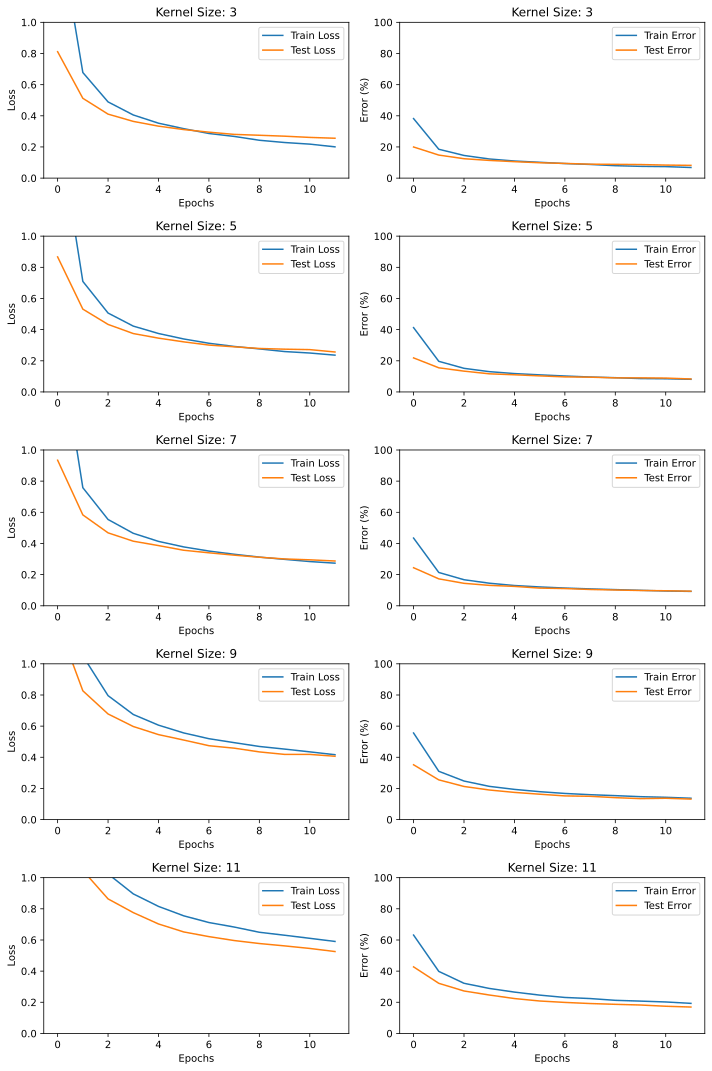

In [ ]:
kernelsizes = [3,5,7,9,11]
trainlosses = []
testlosses = []
trainerrs = []
testerrs = []

for i, kernel in enumerate(kernelsizes):
    kerneltrainlosses = []
    kerneltestlosses = []
    kerneltrainerrs = []
    kerneltesterrs = []

    for j in range(5):
        trainLoss,testLoss,trainErr,testErr,net = function2trainTheModel(channelsinside=6,kernelsize=kernel,padding=1,stride=1,maxpool=2,ffnsize=50)
        kerneltrainlosses.append(trainLoss)
        kerneltestlosses.append(testLoss)
        kerneltrainerrs.append(trainErr)
        kerneltesterrs.append(testErr)
    
    # average over the 5 runs
    trainlosses.append(torch.mean(torch.stack(kerneltrainlosses), axis=0)) 
    testlosses.append(torch.mean(torch.stack(kerneltestlosses), axis=0))
    trainerrs.append(torch.mean(torch.stack(kerneltrainerrs), axis=0))
    testerrs.append(torch.mean(torch.stack(kerneltesterrs), axis=0))

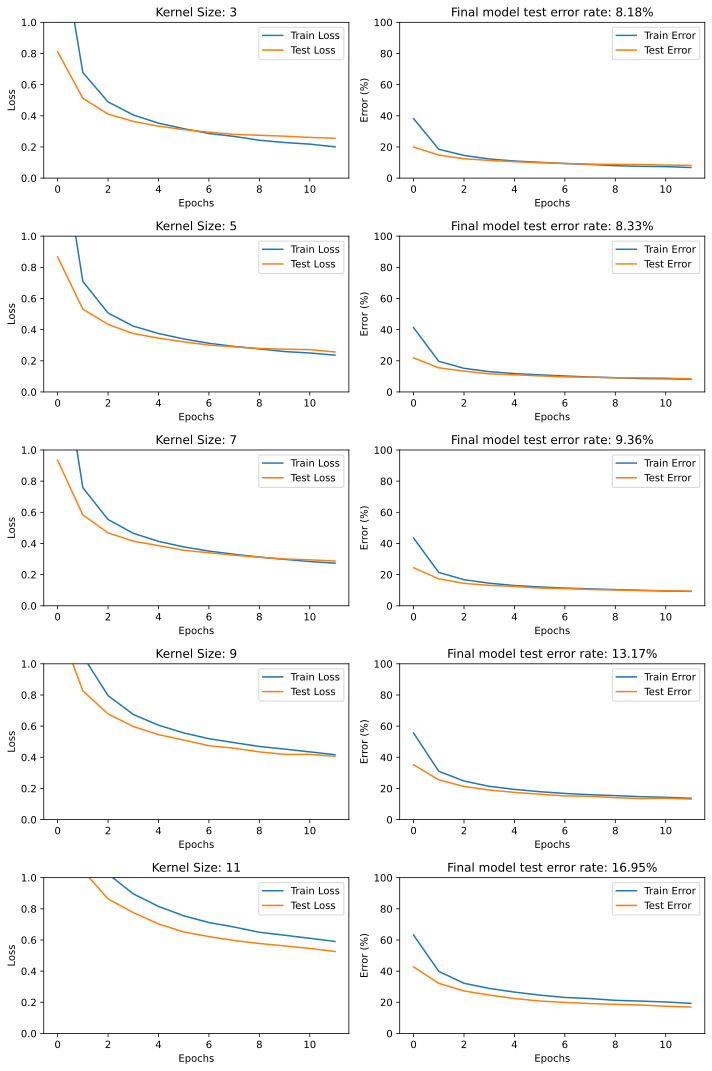

In [23]:
fig,ax = plt.subplots(5,2,figsize=(10,15))

for i, kernel in enumerate(kernelsizes):
    ax[i, 0].plot(trainlosses[kernelsizes.index(kernel)], label='Train Loss')
    ax[i, 0].plot(testlosses[kernelsizes.index(kernel)], label='Test Loss')
    ax[i, 0].set_title(f'Kernel Size: {kernel}')
    ax[i, 0].set_xlabel('Epochs')
    ax[i, 0].set_ylabel('Loss')
    ax[i, 0].set_ylim(0, 1)
    ax[i, 0].legend()

    ax[i, 1].plot(trainerrs[kernelsizes.index(kernel)], label='Train Error')
    ax[i, 1].plot(testerrs[kernelsizes.index(kernel)], label='Test Error')
    ax[i, 1].set_title(f'Final model test error rate: {testerrs[kernelsizes.index(kernel)][-1]:.2f}%')
    ax[i, 1].set_xlabel('Epochs')
    ax[i, 1].set_ylabel('Error (%)')
    ax[i, 1].set_ylim(0, 100)
    ax[i, 1].legend()


plt.tight_layout()
plt.show()

# Number of channels inside the convolutional layers

Keeping a constant number of cnn layers, we will see how many channels we need. To do so, we will do the same test as previously. We aren't going to study the feature maps, as here we are going to choose how many channels, not how many layers. Now we will see the results and in the next cells you'll find the experiments

## Results

We will keep 10 channels for now. We could experiment with more channels, but if the difference between 8 and 10 is already small, I don't think it's worth it to keep exploring.

In [24]:
# Testing randomly different number of channels
channels = [2,4,6,8,10]
trainlosses = []
testlosses = []
trainerrs = []
testerrs = []

for i, channel in enumerate(channels):
    kerneltrainlosses = []
    kerneltestlosses = []
    kerneltrainerrs = []
    kerneltesterrs = []

    for j in range(5):
        trainLoss,testLoss,trainErr,testErr,net = function2trainTheModel(channelsinside=channel,kernelsize=3,padding=1,stride=1,maxpool=2,ffnsize=50)
        kerneltrainlosses.append(trainLoss)
        kerneltestlosses.append(testLoss)
        kerneltrainerrs.append(trainErr)
        kerneltesterrs.append(testErr)
    
    # average over the 5 runs
    trainlosses.append(torch.mean(torch.stack(kerneltrainlosses), axis=0)) 
    testlosses.append(torch.mean(torch.stack(kerneltestlosses), axis=0))
    trainerrs.append(torch.mean(torch.stack(kerneltrainerrs), axis=0))
    testerrs.append(torch.mean(torch.stack(kerneltesterrs), axis=0))

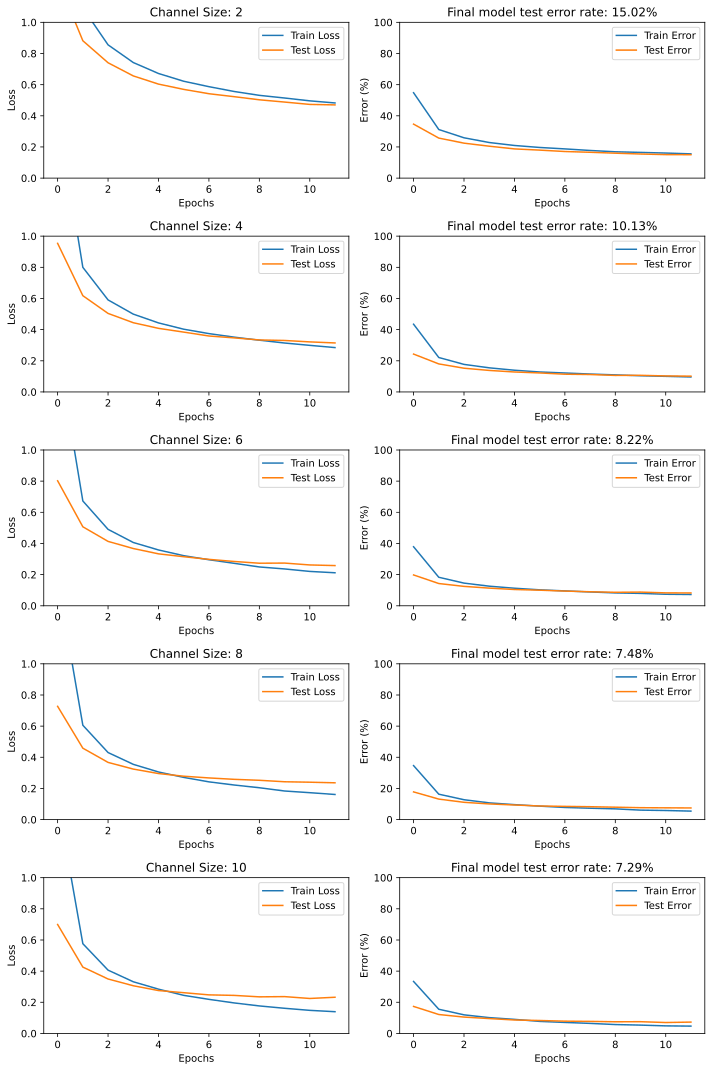

In [25]:
fig,ax = plt.subplots(5,2,figsize=(10,15))

for i, channel in enumerate(channels):
    ax[i, 0].plot(trainlosses[i], label='Train Loss')
    ax[i, 0].plot(testlosses[i], label='Test Loss')
    ax[i, 0].set_title(f'Channel Size: {channel}')
    ax[i, 0].set_xlabel('Epochs')
    ax[i, 0].set_ylabel('Loss')
    ax[i, 0].set_ylim(0, 1)
    ax[i, 0].legend()

    ax[i, 1].plot(trainerrs[i], label='Train Error')
    ax[i, 1].plot(testerrs[i], label='Test Error')
    ax[i, 1].set_title(f'Final model test error rate: {testerrs[i][-1]:.2f}%')
    ax[i, 1].set_xlabel('Epochs')
    ax[i, 1].set_ylabel('Error (%)')
    ax[i, 1].set_ylim(0, 100)
    ax[i, 1].legend()


plt.tight_layout()
plt.show()

# Padding test

We will do, as previously the test of the best padding. We will use the same model as before, but we will change the padding. We will do the test with 0, 1, 2 and 3. The results are bellow 

## Results

According to the results, padding = 2 is the best result

In [37]:
# Testing randomly different number of channels
paddings = [0,1,2,3]
trainlosses = []
testlosses = []
trainerrs = []
testerrs = []
    
for i, padding in enumerate(paddings):
    kerneltrainlosses = []
    kerneltestlosses = []
    kerneltrainerrs = []
    kerneltesterrs = []

    for j in range(5):
        trainLoss,testLoss,trainErr,testErr,net = function2trainTheModel(channelsinside=10,kernelsize=3,padding=padding,stride=1,maxpool=2,ffnsize=50)
        kerneltrainlosses.append(trainLoss)
        kerneltestlosses.append(testLoss)
        kerneltrainerrs.append(trainErr)
        kerneltesterrs.append(testErr)
    
    # average over the 5 runs
    trainlosses.append(torch.mean(torch.stack(kerneltrainlosses), axis=0)) 
    testlosses.append(torch.mean(torch.stack(kerneltestlosses), axis=0))
    trainerrs.append(torch.mean(torch.stack(kerneltrainerrs), axis=0))
    testerrs.append(torch.mean(torch.stack(kerneltesterrs), axis=0))

0
1
2
3


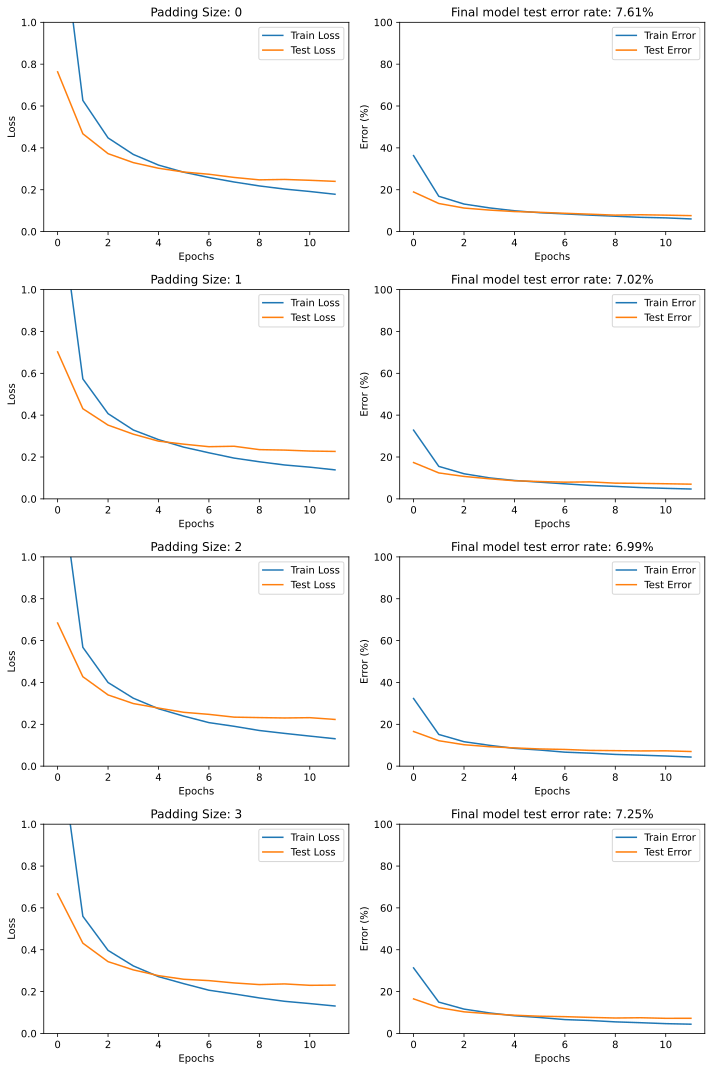

In [38]:
fig,ax = plt.subplots(4,2,figsize=(10,15))

for i, padding in enumerate(paddings):
    print(i)
    ax[i, 0].plot(trainlosses[i], label='Train Loss')
    ax[i, 0].plot(testlosses[i], label='Test Loss')
    ax[i, 0].set_title(f'Padding Size: {padding}')
    ax[i, 0].set_xlabel('Epochs')
    ax[i, 0].set_ylabel('Loss')
    ax[i, 0].set_ylim(0, 1)
    ax[i, 0].legend()

    ax[i, 1].plot(trainerrs[i], label='Train Error')
    ax[i, 1].plot(testerrs[i], label='Test Error')
    ax[i, 1].set_title(f'Final model test error rate: {testerrs[i][-1]:.2f}%')
    ax[i, 1].set_xlabel('Epochs')
    ax[i, 1].set_ylabel('Error (%)')
    ax[i, 1].set_ylim(0, 100)
    ax[i, 1].legend()


plt.tight_layout()
plt.show()

# Stride tests

We are going to experiment now with the stride parameter. As always, the same test but keeping the previous parameters. The results are below

## Results

The best results are with stride 1. It's not worth to add more stride (skipping 2 or more) because the results are much worse.

In [45]:
# Testing randomly different number of channels
strides = [1,2,3]
trainlosses = []
testlosses = []
trainerrs = []
testerrs = []
    
for i, stride in enumerate(strides):
    kerneltrainlosses = []
    kerneltestlosses = []
    kerneltrainerrs = []
    kerneltesterrs = []

    for j in range(5):
        trainLoss,testLoss,trainErr,testErr,net = function2trainTheModel(channelsinside=10,kernelsize=3,padding=2,stride=stride,maxpool=2,ffnsize=50)
        kerneltrainlosses.append(trainLoss)
        kerneltestlosses.append(testLoss)
        kerneltrainerrs.append(trainErr)
        kerneltesterrs.append(testErr)
    
    # average over the 5 runs
    trainlosses.append(torch.mean(torch.stack(kerneltrainlosses), axis=0)) 
    testlosses.append(torch.mean(torch.stack(kerneltestlosses), axis=0))
    trainerrs.append(torch.mean(torch.stack(kerneltrainerrs), axis=0))
    testerrs.append(torch.mean(torch.stack(kerneltesterrs), axis=0))

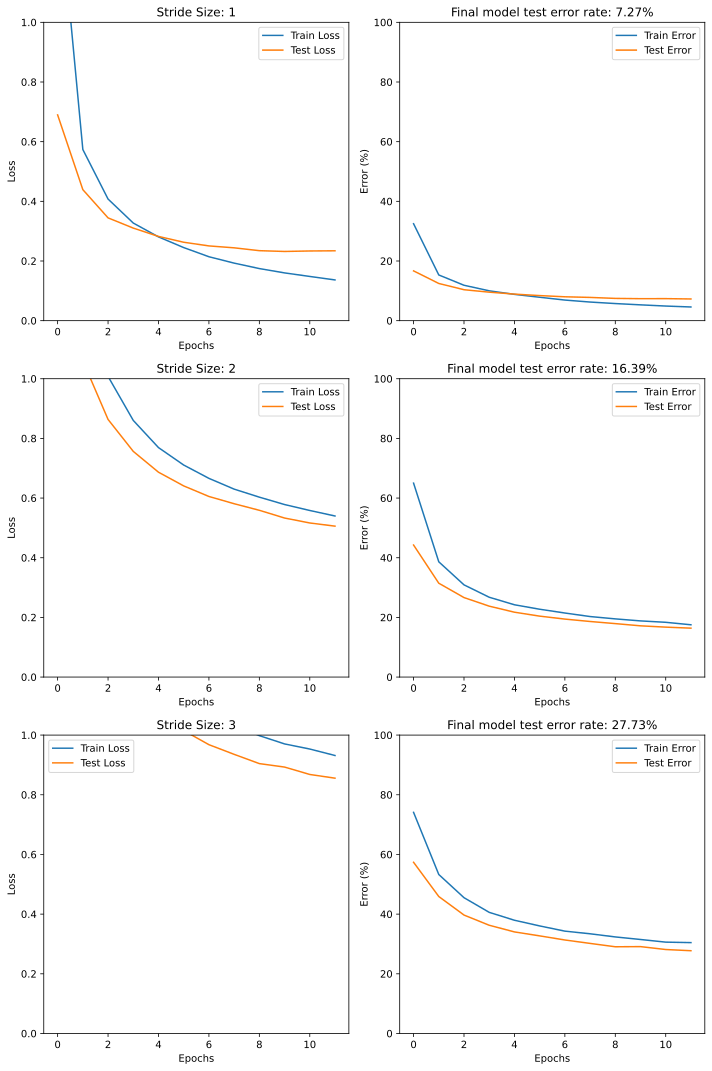

In [46]:
fig,ax = plt.subplots(3,2,figsize=(10,15))

for i, stride in enumerate(strides):
    ax[i, 0].plot(trainlosses[i], label='Train Loss')
    ax[i, 0].plot(testlosses[i], label='Test Loss')
    ax[i, 0].set_title(f'Stride Size: {stride}')
    ax[i, 0].set_xlabel('Epochs')
    ax[i, 0].set_ylabel('Loss')
    ax[i, 0].set_ylim(0, 1)
    ax[i, 0].legend()

    ax[i, 1].plot(trainerrs[i], label='Train Error')
    ax[i, 1].plot(testerrs[i], label='Test Error')
    ax[i, 1].set_title(f'Final model test error rate: {testerrs[i][-1]:.2f}%')
    ax[i, 1].set_xlabel('Epochs')
    ax[i, 1].set_ylabel('Error (%)')
    ax[i, 1].set_ylim(0, 100)
    ax[i, 1].legend()


plt.tight_layout()
plt.show()

# Maxpool test

Now we are going to choose the best maxpool size. We will do the same test as before, but we will change the maxpool size. The results are below

## Results

A maxpool of 2 seems like the best results. Maybe the maxpool of 4 with longer training could be better, but the difference right now between 2 and 4 are way too high to be worth it. We will keep the maxpool of 2 for now.

In [47]:
# Testing randomly different number of channels
maxpools = [1,2,3,4]
trainlosses = []
testlosses = []
trainerrs = []
testerrs = []
    
for i, maxpool in enumerate(maxpools):
    kerneltrainlosses = []
    kerneltestlosses = []
    kerneltrainerrs = []
    kerneltesterrs = []

    for j in range(5):
        trainLoss,testLoss,trainErr,testErr,net = function2trainTheModel(channelsinside=10,kernelsize=3,padding=2,stride=1,maxpool=maxpool,ffnsize=50)
        kerneltrainlosses.append(trainLoss)
        kerneltestlosses.append(testLoss)
        kerneltrainerrs.append(trainErr)
        kerneltesterrs.append(testErr)
    
    # average over the 5 runs
    trainlosses.append(torch.mean(torch.stack(kerneltrainlosses), axis=0)) 
    testlosses.append(torch.mean(torch.stack(kerneltestlosses), axis=0))
    trainerrs.append(torch.mean(torch.stack(kerneltrainerrs), axis=0))
    testerrs.append(torch.mean(torch.stack(kerneltesterrs), axis=0))

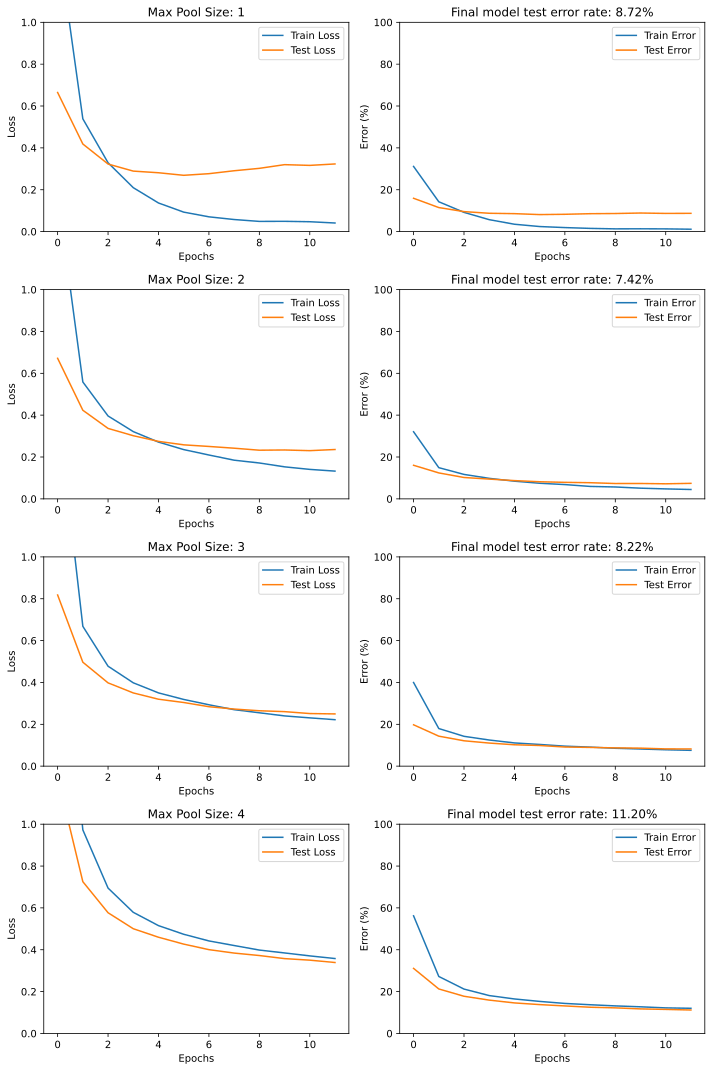

In [48]:
fig,ax = plt.subplots(4,2,figsize=(10,15))

for i, maxpool in enumerate(maxpools):
    ax[i, 0].plot(trainlosses[i], label='Train Loss')
    ax[i, 0].plot(testlosses[i], label='Test Loss')
    ax[i, 0].set_title(f'Max Pool Size: {maxpool}')
    ax[i, 0].set_xlabel('Epochs')
    ax[i, 0].set_ylabel('Loss')
    ax[i, 0].set_ylim(0, 1)
    ax[i, 0].legend()

    ax[i, 1].plot(trainerrs[i], label='Train Error')
    ax[i, 1].plot(testerrs[i], label='Test Error')
    ax[i, 1].set_title(f'Final model test error rate: {testerrs[i][-1]:.2f}%')
    ax[i, 1].set_xlabel('Epochs')
    ax[i, 1].set_ylabel('Error (%)')
    ax[i, 1].set_ylim(0, 100)
    ax[i, 1].legend()


plt.tight_layout()
plt.show()

# FFN units size

Here we are not going to test how many layers we need, but how many units in our two layer ffn model. You'll find the results below

## Results

200 units seems like the best option.

In [ ]:
# Testing randomly different number of channels
ffnsizes = [25,50,100,200]
trainlosses = []
testlosses = []
trainerrs = []
testerrs = []
    
for i, ffnsize in enumerate(ffnsizes):
    kerneltrainlosses = []
    kerneltestlosses = []
    kerneltrainerrs = []
    kerneltesterrs = []

    for j in range(5):
        trainLoss,testLoss,trainErr,testErr,net = function2trainTheModel(channelsinside=10,kernelsize=3,padding=2,stride=1,maxpool=2,ffnsize=ffnsize)
        kerneltrainlosses.append(trainLoss)
        kerneltestlosses.append(testLoss)
        kerneltrainerrs.append(trainErr)
        kerneltesterrs.append(testErr)
    
    # average over the 5 runs
    trainlosses.append(torch.mean(torch.stack(kerneltrainlosses), axis=0)) 
    testlosses.append(torch.mean(torch.stack(kerneltestlosses), axis=0))
    trainerrs.append(torch.mean(torch.stack(kerneltrainerrs), axis=0))
    testerrs.append(torch.mean(torch.stack(kerneltesterrs), axis=0))

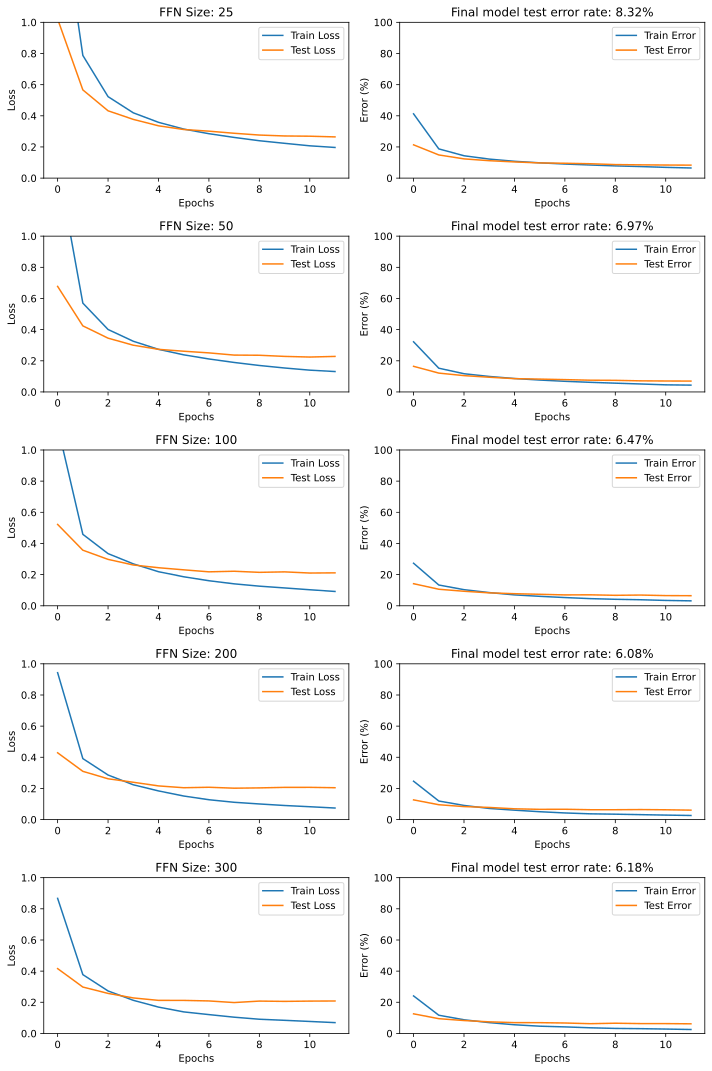

In [55]:
fig,ax = plt.subplots(5,2,figsize=(10,15))

for i, ffnsize in enumerate(ffnsizes):
    ax[i, 0].plot(trainlosses[i], label='Train Loss')
    ax[i, 0].plot(testlosses[i], label='Test Loss')
    ax[i, 0].set_title(f'FFN Size: {ffnsize}')
    ax[i, 0].set_xlabel('Epochs')
    ax[i, 0].set_ylabel('Loss')
    ax[i, 0].set_ylim(0, 1)
    ax[i, 0].legend()

    ax[i, 1].plot(trainerrs[i], label='Train Error')
    ax[i, 1].plot(testerrs[i], label='Test Error')
    ax[i, 1].set_title(f'Final model test error rate: {testerrs[i][-1]:.2f}%')
    ax[i, 1].set_xlabel('Epochs')
    ax[i, 1].set_ylabel('Error (%)')
    ax[i, 1].set_ylim(0, 100)
    ax[i, 1].legend()


plt.tight_layout()
plt.show()

# Testing dropout

Now that we (kinda) know the parameters, we are going to test the dropout. We will do the same test as before, but we will add a dropout layer after the first convolutional layer. The results are below

## Results

In this case we are going to keep the dropout to 0. It looks like it doesn't help, but we will have to see if it continues like this in the validation set.

In [67]:
# Testing randomly different number of channels
dropoutrates = [0.01,0.05,0.1,0.2,0.5]
trainlosses = []
testlosses = []
trainerrs = []
testerrs = []
    
for i, dropoutrate in enumerate(dropoutrates):
    kerneltrainlosses = []
    kerneltestlosses = []
    kerneltrainerrs = []
    kerneltesterrs = []

    for j in range(5):
        trainLoss,testLoss,trainErr,testErr,net = function2trainTheModel(channelsinside=10,kernelsize=3,padding=2,stride=1,maxpool=2,ffnsize=200, dropout=dropoutrate)
        kerneltrainlosses.append(trainLoss)
        kerneltestlosses.append(testLoss)
        kerneltrainerrs.append(trainErr)
        kerneltesterrs.append(testErr)
    
    # average over the 5 runs
    trainlosses.append(torch.mean(torch.stack(kerneltrainlosses), axis=0)) 
    testlosses.append(torch.mean(torch.stack(kerneltestlosses), axis=0))
    trainerrs.append(torch.mean(torch.stack(kerneltrainerrs), axis=0))
    testerrs.append(torch.mean(torch.stack(kerneltesterrs), axis=0))

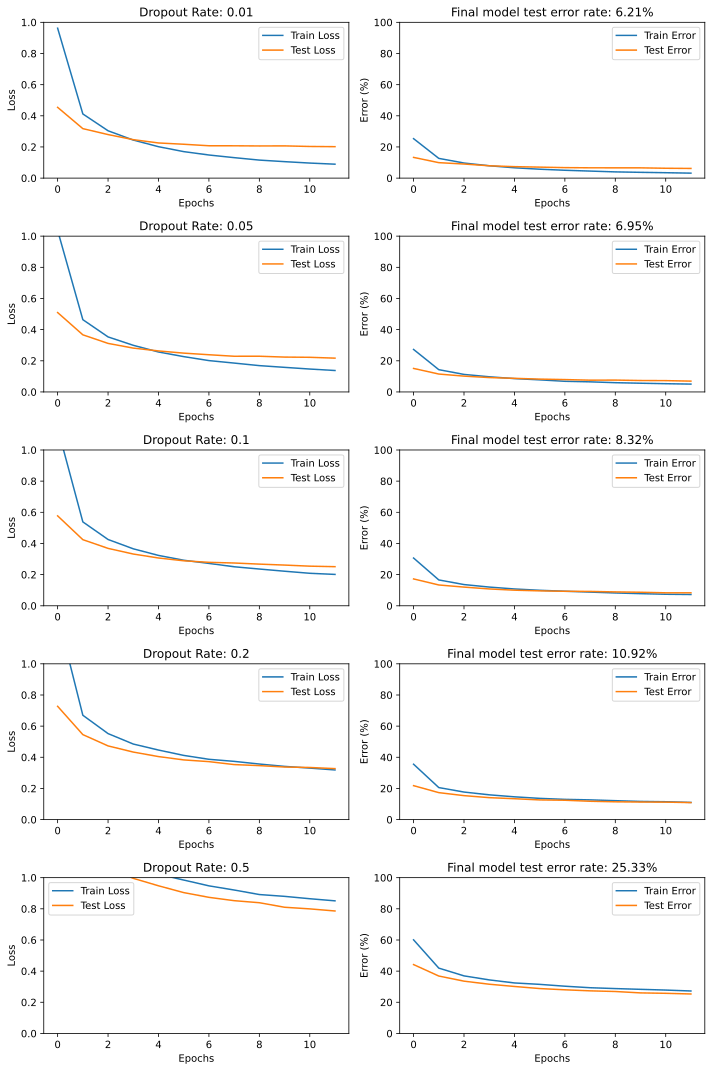

In [70]:
fig,ax = plt.subplots(5,2,figsize=(10,15))

for i, dropoutrate in enumerate(dropoutrates):
    ax[i, 0].plot(trainlosses[i], label='Train Loss')
    ax[i, 0].plot(testlosses[i], label='Test Loss')
    ax[i, 0].set_title(f'Dropout Rate: {dropoutrate}')
    ax[i, 0].set_xlabel('Epochs')
    ax[i, 0].set_ylabel('Loss')
    ax[i, 0].set_ylim(0, 1)
    ax[i, 0].legend()

    ax[i, 1].plot(trainerrs[i], label='Train Error')
    ax[i, 1].plot(testerrs[i], label='Test Error')
    ax[i, 1].set_title(f'Final model test error rate: {testerrs[i][-1]:.2f}%')
    ax[i, 1].set_xlabel('Epochs')
    ax[i, 1].set_ylabel('Error (%)')
    ax[i, 1].set_ylim(0, 100)
    ax[i, 1].legend()


plt.tight_layout()
plt.show()

# FFN Layers

Here we are going to test how many layers we need in the FFN. We will do a similar test as before, but here we will do many cases. 

We have to take into account that we decided to have 200 units in two layers in the ffn, but depending the layers maybe we have better results. So we will try different cases in 3 categories:

1. Keep 400 units (2x200), divided in x layers
2. Keep 400 units, but 400 units in each layer
3. Do a remix and try different things. If these results are better, we might have to rerun everything again.

So the tests cases will be all the combinations of:

- 1, 2, 3, 4 layers
- 100, 200, 400 units

This will generate a total of 12 combinations. Remember that each combination will be trained 5 times to get the average and remove the luck factor. If any of these results do not follow the rules 1 or 2, we might try everything again. 

We exepect that the best results will be:
- 2 layers, 200 units
- 4 layers, 100 units
- 3 layers, 100/200 units

## Results
The results are below. We will keep the 2 layers and 200 units for now. It was one of the expected winners, so everything goes according to plan.

In [106]:
# Testing randomly different number of channels
layers = [1, 2, 3, 4]
units = [100, 200, 400]
trainlosses = [[0 for _ in range(len(units))] for _ in range(len(layers))]
testlosses = [[0 for _ in range(len(units))] for _ in range(len(layers))]
trainerrs = [[0 for _ in range(len(units))] for _ in range(len(layers))]
testerrs = [[0 for _ in range(len(units))] for _ in range(len(layers))]

for i, layer in enumerate(layers):
    for j, unit in enumerate(units):
        kerneltrainlosses = []
        kerneltestlosses = []
        kerneltrainerrs = []
        kerneltesterrs = []

        for _ in range(5):
            trainLoss,testLoss,trainErr,testErr,net = function2trainTheModel(ffnnumberlayers=layer,channelsinside=10,kernelsize=3,padding=2,stride=1,maxpool=2,ffnsize=unit)
            kerneltrainlosses.append(trainLoss)
            kerneltestlosses.append(testLoss)
            kerneltrainerrs.append(trainErr)
            kerneltesterrs.append(testErr)
        
        # average over the 5 runs
        trainlosses[i][j] = torch.mean(torch.stack(kerneltrainlosses), axis=0)
        testlosses[i][j] = torch.mean(torch.stack(kerneltestlosses), axis=0)
        trainerrs[i][j] = torch.mean(torch.stack(kerneltrainerrs), axis=0)
        testerrs[i][j] = torch.mean(torch.stack(kerneltesterrs), axis=0)

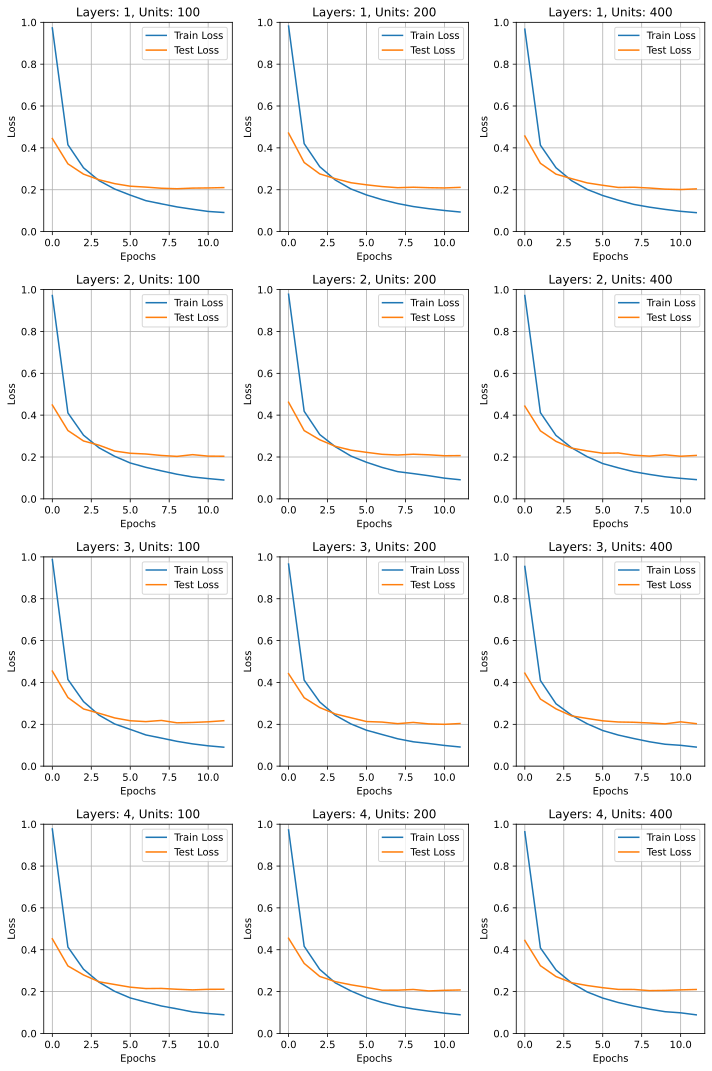

In [ ]:
fig,ax = plt.subplots(4,3,figsize=(10,15))

for i, layer in enumerate(layers):
    for j, unit in enumerate(units):
        ax[i, j].plot(trainlosses[i][j], label='Train Loss')
        ax[i, j].plot(testlosses[i][j], label='Test Loss')
        ax[i, j].set_title(f'Layers: {layer}, Units: {unit}')
        ax[i, j].set_xlabel('Epochs')
        ax[i, j].set_ylabel('Loss')
        ax[i, j].set_ylim(0, 1)
        ax[i, j].legend()
        ax[i, j].grid(True)

plt.tight_layout()
plt.show()

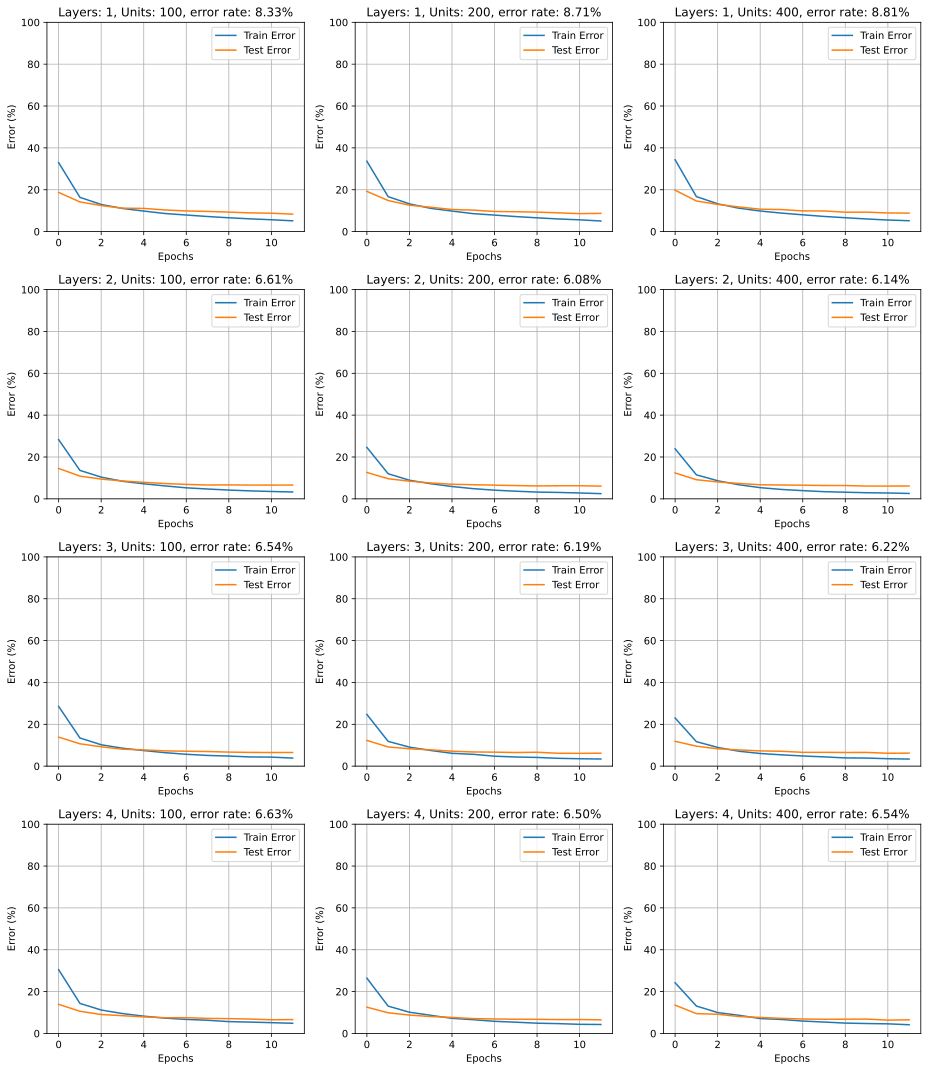

In [107]:
fig,ax = plt.subplots(4,3,figsize=(13,15))

for i, layer in enumerate(layers):
    for j, unit in enumerate(units):
        ax[i, j].plot(trainerrs[i][j], label='Train Error')
        ax[i, j].plot(testerrs[i][j], label='Test Error')
        ax[i, j].set_title(f'Layers: {layer}, Units: {unit}, error rate: {testerrs[i][j][-1]:.2f}%')
        ax[i, j].set_xlabel('Epochs')
        ax[i, j].set_ylabel('Error (%)')
        ax[i, j].set_ylim(0, 100)
        ax[i, j].legend()
        ax[i, j].grid(True)


plt.tight_layout()
plt.show()

# Study the feature maps

Here we know that we should have 10 feature maps, but now we are going to study how many layers. Once again we are going to do like in the ffn, put 3 cases:

1. 10 feature maps are the correct size, so we are going to divide them between the layers
2. 10 feature maps are the correct size, so we are going to put 10 in each layer
3. As we change the number of layers, we should also change the number of feature maps. So let's remix and see what we get

So the tests cases will be all the combinations of:

- 1, 2, 3, 4 layers
- 2, 4, 6, 8, 10 feature maps

This will generate a total of 20 combinations. Remember that each combination will be trained 5 times to get the average and remove the luck factor. If any of these results do not follow the rules 1 or 2, we might try everything again. 

We expect that the best results will be:
- 1 layer, 10 feature maps
- 2 layers, 4/6 feature maps. Or 2 layers 10 feature maps
- 3 layers, 2/4 feature maps. or 2 layers 10 feature maps
- 4 layers, 2 feature maps. Or 2 layers 10 feature maps

## Results

The actual configuraiton looks good but probably needs more training in some cases. We will conduct in the next section some extra training.

In [109]:
layers = [1, 2, 3, 4]
fmaps = [2,4,6,8,10]
trainlosses = [[0 for _ in range(len(fmaps))] for _ in range(len(layers))]
testlosses = [[0 for _ in range(len(fmaps))] for _ in range(len(layers))]
trainerrs = [[0 for _ in range(len(fmaps))] for _ in range(len(layers))]
testerrs = [[0 for _ in range(len(fmaps))] for _ in range(len(layers))]

for i, layer in enumerate(layers):
    for j, fmap in enumerate(fmaps):
        kerneltrainlosses = []
        kerneltestlosses = []
        kerneltrainerrs = []
        kerneltesterrs = []

        for _ in range(5):
            trainLoss,testLoss,trainErr,testErr,net = function2trainTheModel(ffnnumberlayers=2,cnnnumberlayers=layer,channelsinside=fmap,kernelsize=3,padding=2,stride=1,maxpool=2,ffnsize=200)
            kerneltrainlosses.append(trainLoss)
            kerneltestlosses.append(testLoss)
            kerneltrainerrs.append(trainErr)
            kerneltesterrs.append(testErr)
        
        # average over the 5 runs
        trainlosses[i][j] = torch.mean(torch.stack(kerneltrainlosses), axis=0)
        testlosses[i][j] = torch.mean(torch.stack(kerneltestlosses), axis=0)
        trainerrs[i][j] = torch.mean(torch.stack(kerneltrainerrs), axis=0)
        testerrs[i][j] = torch.mean(torch.stack(kerneltesterrs), axis=0)

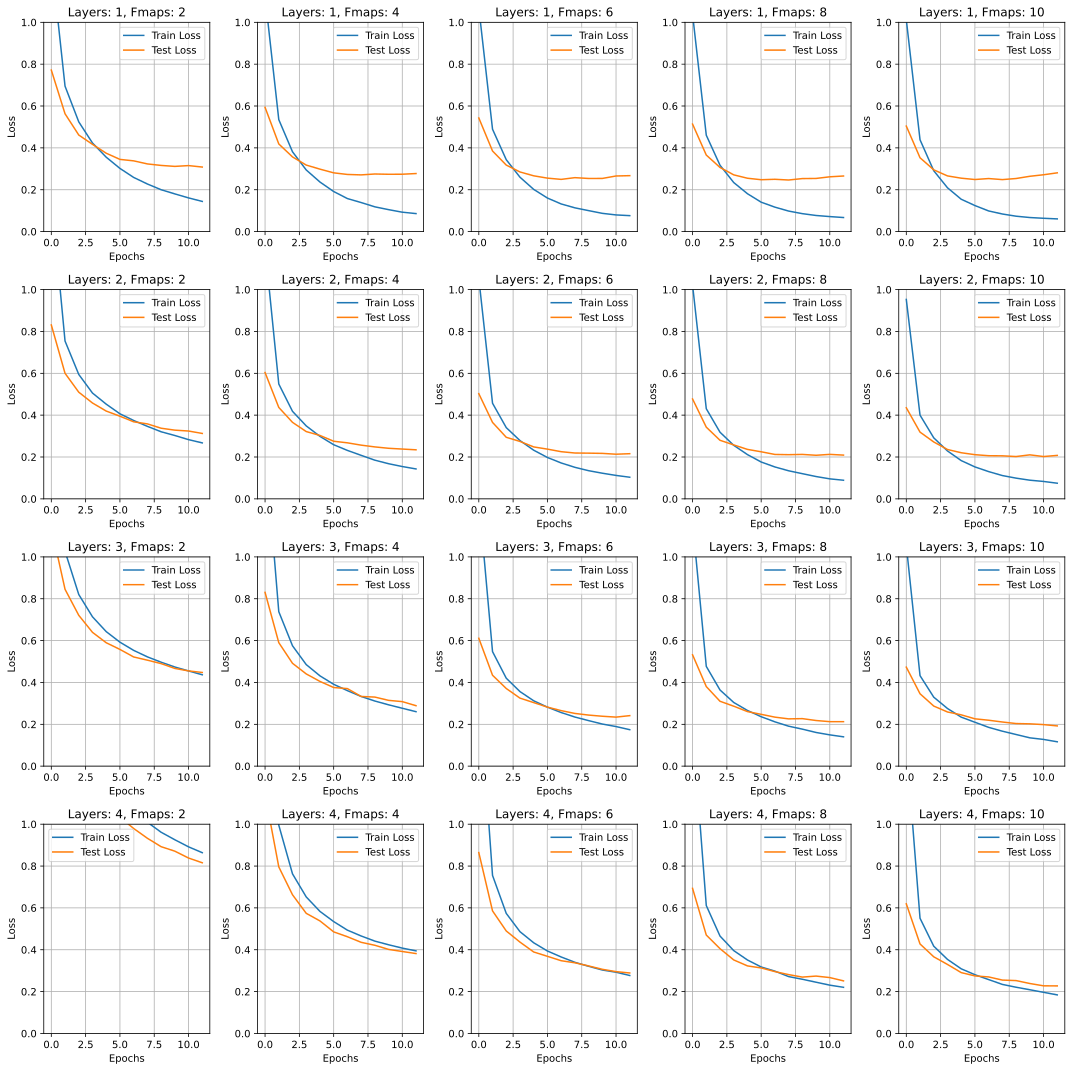

In [117]:
fig,ax = plt.subplots(4,5,figsize=(15,15))

for i, layer in enumerate(layers):
    for j, fmap in enumerate(fmaps):
        ax[i, j].plot(trainlosses[i][j], label='Train Loss')
        ax[i, j].plot(testlosses[i][j], label='Test Loss')
        ax[i, j].set_title(f'Layers: {layer}, Fmaps: {fmap}')
        ax[i, j].set_xlabel('Epochs')
        ax[i, j].set_ylabel('Loss')
        ax[i, j].set_ylim(0, 1)
        ax[i, j].legend()
        ax[i, j].grid(True)

plt.tight_layout()
plt.show()

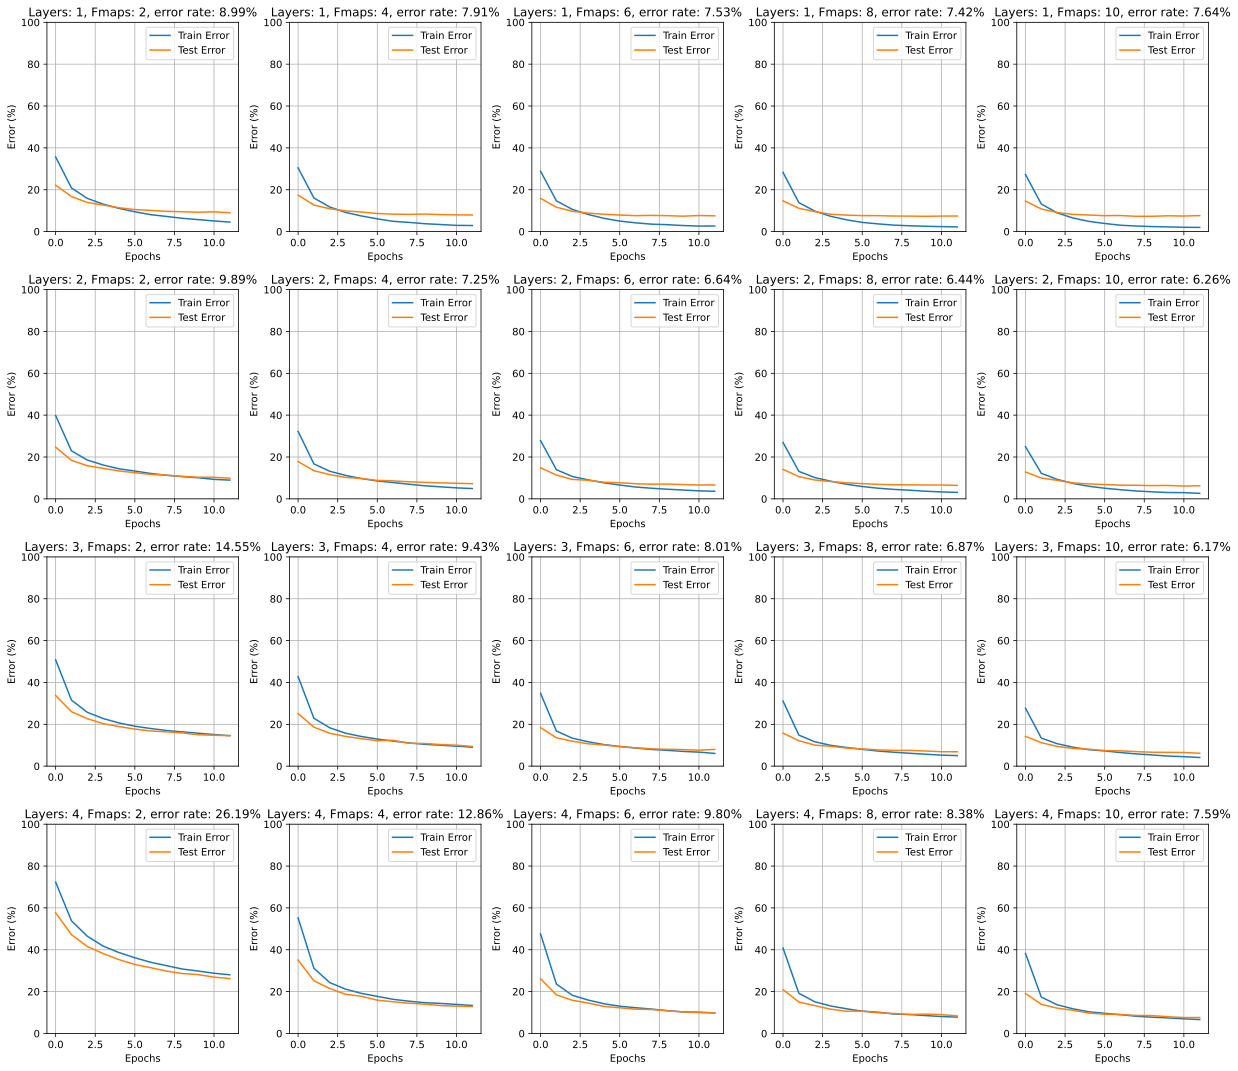

In [120]:
fig,ax = plt.subplots(4,5,figsize=(17,15))

for i, layer in enumerate(layers):
    for j, fmap in enumerate(fmaps):
        ax[i, j].plot(trainerrs[i][j], label='Train Error')
        ax[i, j].plot(testerrs[i][j], label='Test Error')
        ax[i, j].set_title(f'Layers: {layer}, Fmaps: {fmap}, error rate: {testerrs[i][j][-1]:.2f}%')
        ax[i, j].set_xlabel('Epochs')
        ax[i, j].set_ylabel('Error (%)')
        ax[i, j].set_ylim(0, 100)
        ax[i, j].legend()
        ax[i, j].grid(True)


plt.tight_layout()
plt.show()

# Extra study for layers 

We feel that 3 and 4 layers show promising results. We are going to do more testing and more iterations. Right now we only do 12 iterations, and I feel like the 3 and 4 layers could iterate more and get the error rate lower. Or at least the loss graphs show that they still can learn. We will prepare some extra cases:

- 4 layers
  - 2 & 4 units with a lot of epochs. Just to try
  - 6 & 8 & 10 & 12 with more epochs. Looks promising
- 3 layers 
  - 2 & 4 units with more epochs. Probably useless, but let's try
  - 10 & 12 units with more epochs. Looks promising
- 2 layers
  - 10 & 12 units with more epochs. I don't think it will work, but it looks good

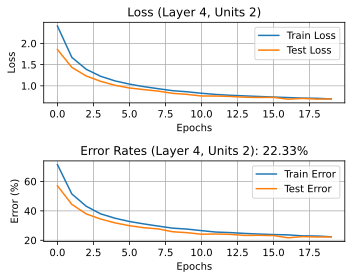

Plots updated for Layer 4, Units 2!


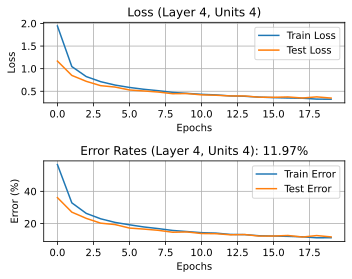

Plots updated for Layer 4, Units 4!


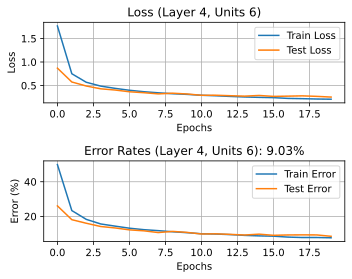

Plots updated for Layer 4, Units 6!


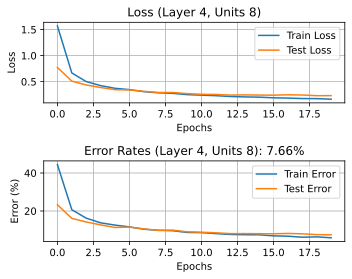

Plots updated for Layer 4, Units 8!


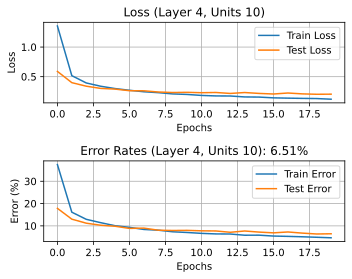

Plots updated for Layer 4, Units 10!


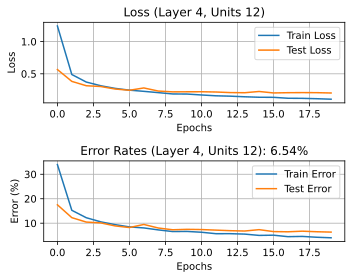

Plots updated for Layer 4, Units 12!


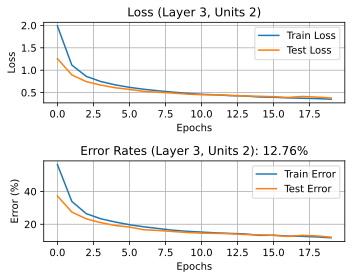

Plots updated for Layer 3, Units 2!


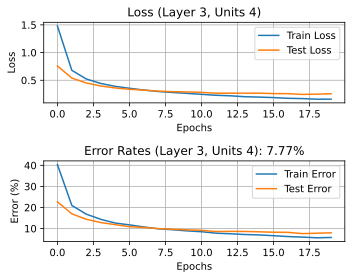

Plots updated for Layer 3, Units 4!


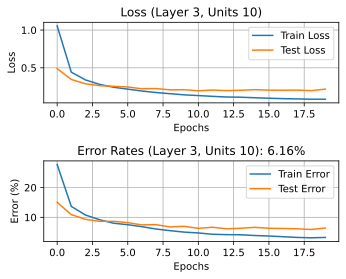

Plots updated for Layer 3, Units 10!


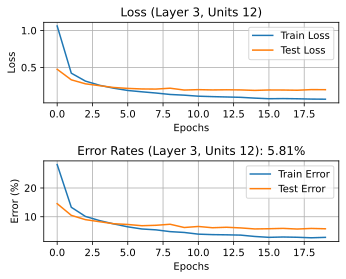

Plots updated for Layer 3, Units 12!


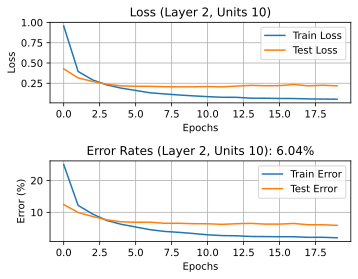

Plots updated for Layer 2, Units 10!


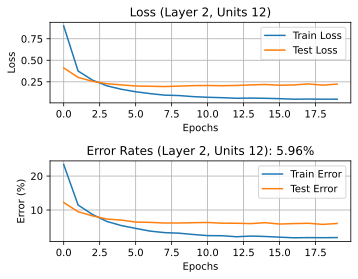

Plots updated for Layer 2, Units 12!


In [134]:
# ARREGLAR QUE SE VEAN TODAS LAS IMÁGENES A LA VEZ

# Define the specific configurations for layers and units
configurations = {
    4: [2, 4, 6, 8, 10, 12],  # 4 layers with specified units
    3: [2, 4, 10, 12],        # 3 layers with specified units
    2: [10, 12]               # 2 layers with specified units
}

# Initialize dictionaries to store results
trainlosses = {}
testlosses = {}
trainerrs = {}
testerrs = {}

# Initialize dictionaries to store figures for each configuration
figures = {}

# Enable interactive mode for dynamic updates
plt.ion()

# Loop through the configurations
for layer, units_list in configurations.items():
    trainlosses[layer] = {}
    testlosses[layer] = {}
    trainerrs[layer] = {}
    testerrs[layer] = {}
    figures[layer] = {}

    for units in units_list:
        kerneltrainlosses = []
        kerneltestlosses = []
        kerneltrainerrs = []
        kerneltesterrs = []

        # Train the model for each configuration
        for _ in range(2):  # Reduced repetitions from 5 to 2
            trainLoss, testLoss, trainErr, testErr, net = function2trainTheModel(
                ffnnumberlayers=2, cnnnumberlayers=layer, channelsinside=units,
                kernelsize=3, padding=2, stride=1, maxpool=2, ffnsize=200, numepochs=20  # Adjust epochs as needed
            )
            kerneltrainlosses.append(trainLoss)
            kerneltestlosses.append(testLoss)
            kerneltrainerrs.append(trainErr)
            kerneltesterrs.append(testErr)

        # Store the averaged results
        trainlosses[layer][units] = torch.mean(torch.stack(kerneltrainlosses), axis=0)
        testlosses[layer][units] = torch.mean(torch.stack(kerneltestlosses), axis=0)
        trainerrs[layer][units] = torch.mean(torch.stack(kerneltrainerrs), axis=0)
        testerrs[layer][units] = torch.mean(torch.stack(kerneltesterrs), axis=0)

        # Create and display separate plots for each configuration dynamically
        fig, (ax_loss, ax_acc) = plt.subplots(2, 1, figsize=(5, 4))

        # Plot losses
        ax_loss.plot(trainlosses[layer][units], label='Train Loss')
        ax_loss.plot(testlosses[layer][units], label='Test Loss')
        ax_loss.set_title(f'Loss (Layer {layer}, Units {units})')
        ax_loss.set_xlabel('Epochs')
        ax_loss.set_ylabel('Loss')
        ax_loss.legend()
        ax_loss.grid(True)

        # Plot accuracies
        avg_test_err = torch.mean(testerrs[layer][units][-3:]).item()  # Average of last 3 epochs
        ax_acc.plot(trainerrs[layer][units], label='Train Error')
        ax_acc.plot(testerrs[layer][units], label='Test Error')
        ax_acc.set_title(f'Error Rates (Layer {layer}, Units {units}): {avg_test_err:.2f}%')
        ax_acc.set_xlabel('Epochs')
        ax_acc.set_ylabel('Error (%)')
        ax_acc.legend()
        ax_acc.grid(True)

        plt.tight_layout()

        # Show the plot dynamically
        plt.show()
        plt.pause(0.1)  # Pause to allow the plot to update

        print(f"Plots updated for Layer {layer}, Units {units}!")

# Disable interactive mode after all runs
plt.ioff()

# Run the model and show the results!

This is our decision. 3 cnn layers with 12 channels inside. Then 2 ffn layers with 200 units each. Maxpool of 2, kernel of 3x3, padding of 2 and stride of 1.

I don't know if it's the best model, and according to the video we could take it down to an error of 3/4%, but I don't know how. The video does a enormous model with very similar results because it only runs it once. I think our model is quite good, smaller and with similar results. 

Also, our results are made with experiments and not randomly. Now we are going to use the validation set to see if the model is good or not.


In [169]:
# ~2 minutes with 10 epochs on GPU (8 mins on the CPU!)
trainLoss,testLoss,trainErr,testErr,net = function2trainTheModel(
                ffnnumberlayers=2, cnnnumberlayers=3, channelsinside=12,
                kernelsize=3, padding=2, stride=1, maxpool=2, ffnsize=200, 
                numepochs=20, val=False
            )

# ~2 minutes with 10 epochs on GPU (8 mins on the CPU!)
trainLoss,valLoss,trainErr,valErr,net = function2trainTheModel(
                ffnnumberlayers=2, cnnnumberlayers=3, channelsinside=12,
                kernelsize=3, padding=2, stride=1, maxpool=2, ffnsize=200, 
                numepochs=20, val=True
            )

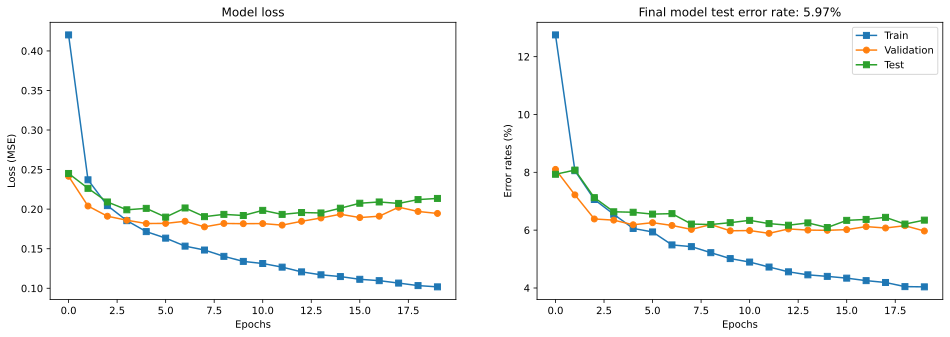

In [170]:
fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(trainLoss,'s-',label='Train')
ax[0].plot(testLoss,'o-',label='Test')
ax[0].plot(valLoss,'s-',label='Val')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss (MSE)')
ax[0].set_title('Model loss')

ax[1].plot(trainErr,'s-',label='Train')
ax[1].plot(testErr,'o-',label='Validation')
ax[1].plot(valErr,'s-',label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Error rates (%)')
ax[1].set_title(f'Final model test error rate: {testErr[-1]:.2f}%')
ax[1].legend()

plt.show()

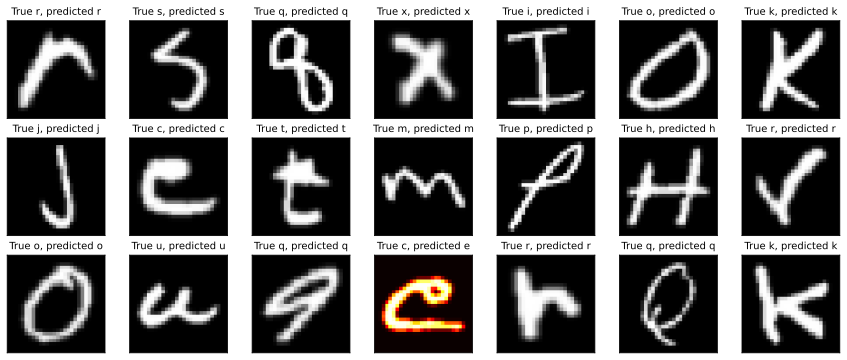

In [137]:
### visualize some images

# extract X,y from test dataloader
X,y = next(iter(test_loader))
X = X.to(device) # push data to GPU
y = y.to(device) # push data to GPU
yHat = net(X)

# pick some examples at random to show
randex = np.random.choice(len(y),size=21,replace=False)

# visualize some images
fig,axs = plt.subplots(3,7,figsize=(15,6))

for i,ax in enumerate(axs.flatten()):

  # extract the image and its target letter
  I = np.squeeze( X[randex[i],0,:,:] ).cpu() # .cpu() to transfer back from GPU!
  trueLetter = letterCategories[ y[randex[i]] ]
  predLetter = letterCategories[ torch.argmax(yHat[randex[i],:]) ]
  
  # color-code the accuracy (using ternary operator)
  col = 'gray' if trueLetter==predLetter else 'hot'
  
  # visualize
  ax.imshow(I.T,cmap=col)
  ax.set_title('True %s, predicted %s' %(trueLetter,predLetter),fontsize=10)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Accuracy by letter

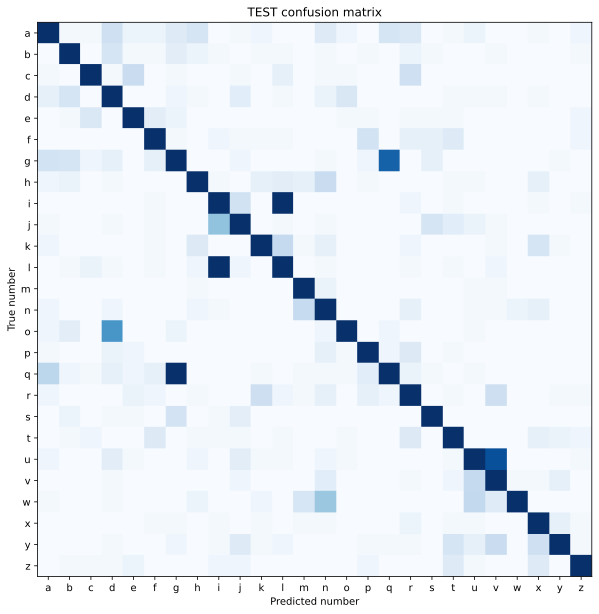

In [138]:
import sklearn.metrics as skm

# compute the confusion matrix
C = skm.confusion_matrix(y.cpu(),torch.argmax(yHat.cpu(),axis=1),normalize='true')

# visualize it
fig = plt.figure(figsize=(10,10))
plt.imshow(C,'Blues',vmax=.05)

# make the plot look nicer
plt.xticks(range(26),labels=letterCategories)
plt.yticks(range(26),labels=letterCategories)
plt.title('TEST confusion matrix')
plt.xlabel('True number')
plt.xlabel('Predicted number')
plt.ylabel('True number')

plt.show()

# Additional explorations

In [20]:
# 1) I added batch normalization to the convolution layers, but not to the linear (fc*) layers. But linear layers also 
#    benefit from batchnorm just like convolution layers do. Add it!
#
#    Done and works better!
# 
# 2) In the next few videos, we will see whether we can improve the model's performance by experimenting with the number
#    of layers, kernel size, and linear-layer units. Is there anything you could think of, other than these three features,
#    that might help boost model performance?
#
#    I think that the linear-layers shouldn't be expanded, as per previous experience it works already well. We could explore
#    stuff like more layers or kernel size. We could study the feature maps and their impact on the model's accuracy.